In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

In [2]:
# Load dataset
data  = np.genfromtxt('training-val-test-data.csv', delimiter=',', skip_header=1)
u_all  = data[:, 0]   # input voltage [V]
th_all = data[:, 1]   # disk angle [rad]

N = len(u_all)
print(f"Samples: {N}")
print(f"u  — min: {u_all.min():.3f} V,  max: {u_all.max():.3f} V")
print(f"θ  — min: {np.degrees(th_all.min()):.1f}°,  max: {np.degrees(th_all.max()):.1f}°,  std: {np.degrees(th_all.std()):.1f}°")

Samples: 35000
u  — min: -3.103 V,  max: 3.337 V
θ  — min: -108.9°,  max: 124.9°,  std: 27.5°


In [3]:
# We create contiguous sets to avoid data leakage
split_train = int(0.70 * N) 
split_val   = int(0.85 * N)  

u_train,  th_train  = u_all[:split_train],          th_all[:split_train]
u_val,    th_val    = u_all[split_train:split_val],  th_all[split_train:split_val]
u_test,   th_test   = u_all[split_val:],             th_all[split_val:]

print(f"Training  : {len(u_train):>6} samples")
print(f"Validation: {len(u_val):>6} samples")
print(f"Test      : {len(u_test):>6} samples")

Training  :  24500 samples
Validation:   5250 samples
Test      :   5250 samples


### Time domain plot

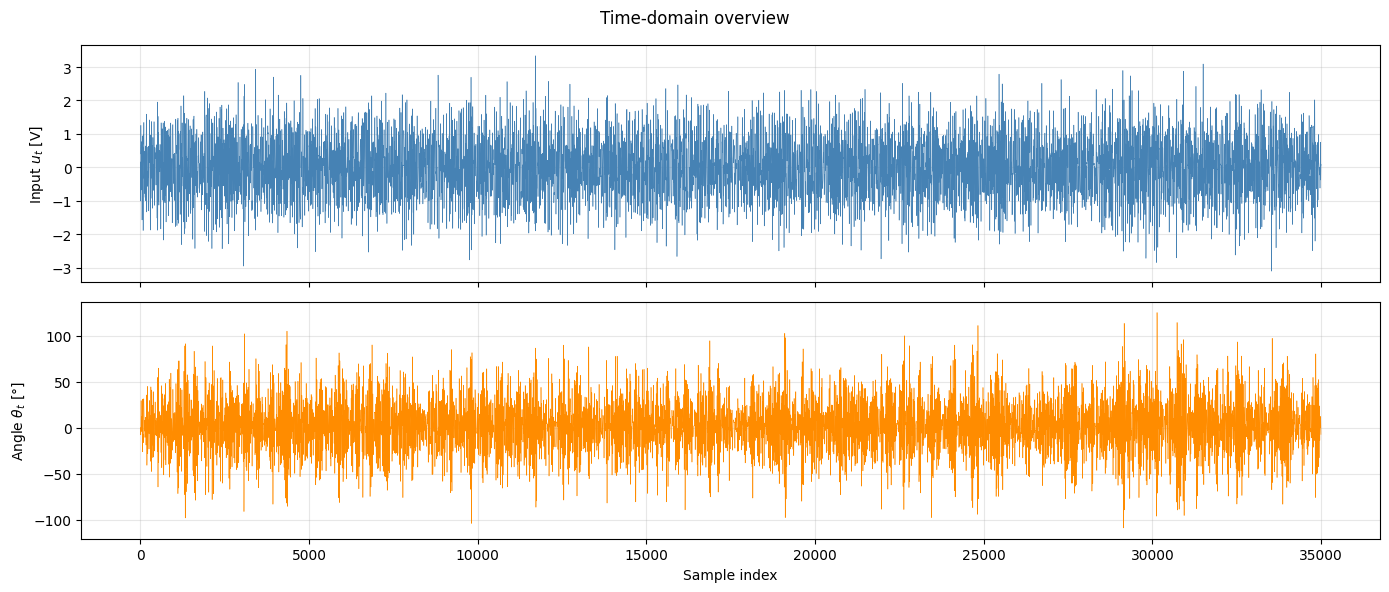

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(u_all, lw=0.4, color='steelblue')
axes[0].set_ylabel("Input $u_t$ [V]") 
axes[0].grid(alpha=0.3)
axes[1].plot(np.degrees(th_all), lw=0.4, color='darkorange')
axes[1].set_ylabel("Angle $\\theta_t$ [°]"); 
axes[1].set_xlabel("Sample index")
axes[1].grid(alpha=0.3)
plt.suptitle("Time-domain overview", fontsize=12)
plt.tight_layout(); plt.show()

### Histogram of θ

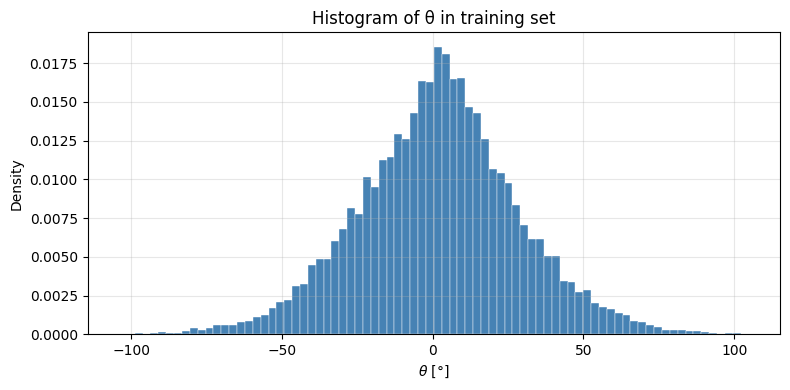

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(np.degrees(th_train), bins=80, density=True,
        color='steelblue', edgecolor='white', linewidth=0.3)

ax.set_xlabel("$\\theta$ [°]"); ax.set_ylabel("Density")
ax.set_title("Histogram of θ in training set")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Noise Level Estimation

In [6]:
# Variance of Δθ on Near-static segments ≈ 2σ_e²  (differencing doubles the noise variance)
static_mask = np.abs(u_train[1:]) < 0.1
dth_static  = np.diff(th_train)[static_mask]

sigma_e_est  = np.std(dth_static) / np.sqrt(2)
sigma_e2_est = sigma_e_est ** 2

print(f"Near-static samples used: {static_mask.sum()}")
print(f"Estimated σ_e  ≈ {sigma_e_est:.5f} rad  ({np.degrees(sigma_e_est):.3f}°)")
print(f"Estimated σ_e² ≈ {sigma_e2_est:.6f} rad²")

Near-static samples used: 2306
Estimated σ_e  ≈ 0.08291 rad  (4.750°)
Estimated σ_e² ≈ 0.006874 rad²


### NARX construction

In [7]:
def make_training_data(u, th, na, nb):
    X, Y = [], []
    for k in range(max(na, nb), len(u)):
        X.append([th[k-i] for i in range(1, na+1)] + [u[k]])
        Y.append(th[k])
    return np.array(X), np.array(Y)

na, nb = 2, 1

Xtrain, Ytrain = make_training_data(u_train, th_train, na, nb)
Xval,   Yval   = make_training_data(u_val,   th_val,   na, nb)

print(f"Xtrain shape: {Xtrain.shape}")
print(f"Xval shape: {Xval.shape}")


Xtrain shape: (24498, 3)
Xval shape: (5248, 3)


### Best Fit Rate

In [8]:
# Best Fit Rate (BFR) metric

def BFR(y_true, y_pred):
    num = np.sqrt(np.sum((y_true - y_pred)**2))
    den = np.sqrt(np.sum((y_true - np.mean(y_true))**2))
    return 100 * max(1 - num/den, 0)

### Baseline GP with 500 samples

In [9]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

ker = RBF(length_scale=0.5) + WhiteKernel(noise_level=sigma_e2_est)
reg = GaussianProcessRegressor(ker, n_restarts_optimizer=3)
reg.fit(Xtrain[:500], Ytrain[:500])

Ypred_val = reg.predict(Xval[:200])
print(f"Baseline BFR: {BFR(Yval[:200], Ypred_val):.1f}%")
print(f"Optimised kernel: {reg.kernel_}")

Baseline BFR: 94.5%
Optimised kernel: RBF(length_scale=2.65) + WhiteKernel(noise_level=4.87e-05)


### $n_a$ sweep

In [13]:
na_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
bfr_results = {}

for na_now in na_list:
    X_sw, Y_sw = make_training_data(u_train[:2002], th_train[:2002], na=na_now, nb=1)
    X_vw, Y_vw = make_training_data(u_val[:802],   th_val[:802],   na=na_now, nb=1)

    ker_sw = RBF(length_scale=0.5) + WhiteKernel(noise_level=sigma_e2_est)
    reg_sw = GaussianProcessRegressor(ker_sw, n_restarts_optimizer=3)
    reg_sw.fit(X_sw, Y_sw)

    Yp_vw = reg_sw.predict(X_vw)
    bfr_results[na_now] = BFR(Y_vw, Yp_vw)
    print(f"na={na_now}: prediction BFR = {bfr_results[na_now]:.1f}%")

na=1: prediction BFR = 77.0%
na=2: prediction BFR = 98.5%
na=3: prediction BFR = 98.9%
na=4: prediction BFR = 99.1%
na=5: prediction BFR = 99.0%
na=6: prediction BFR = 99.0%
na=7: prediction BFR = 99.1%
na=8: prediction BFR = 99.1%


c:\Users\konst\miniconda3\envs\gpy_env\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 8 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


na=9: prediction BFR = 99.1%
na=10: prediction BFR = 99.1%


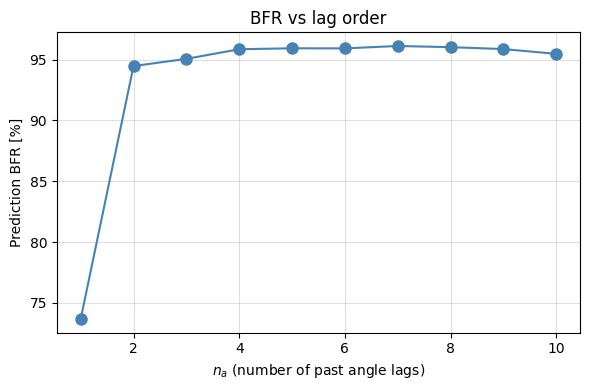

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(na_list, [bfr_results[n] for n in na_list], 'o-', color='steelblue', ms=8)
ax.set_xlabel("$n_a$ (number of past angle lags)")
ax.set_ylabel("Prediction BFR [%]")
ax.set_title("BFR vs lag order")

ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()


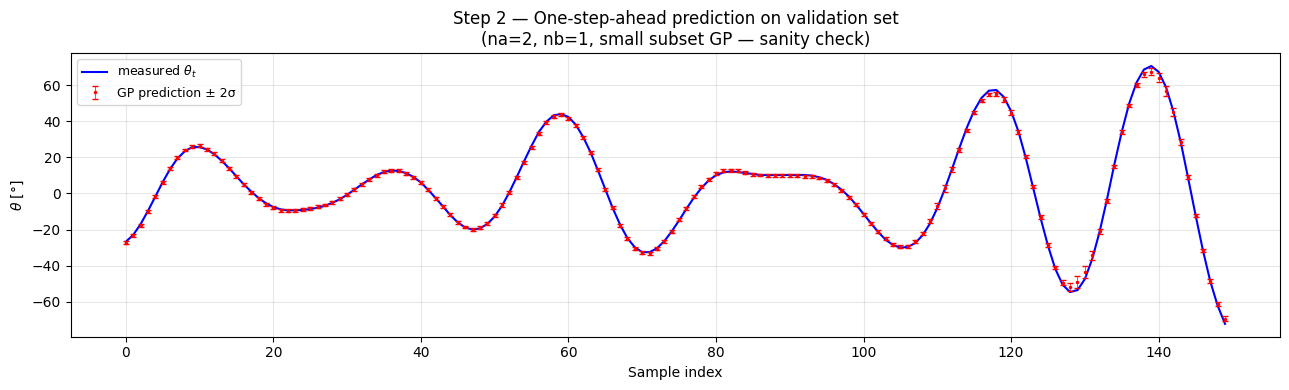

Prediction BFR on validation: 96.4%


In [12]:
# From Exercise 5 Cell 48 pattern: plot measured vs predicted with uncertainty bars
# Uses the baseline reg fitted in Cell 3

Ypred_plot, Ystd_plot = reg.predict(Xval[:150], return_std=True)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(np.degrees(Yval[:150]), 'b', lw=1.5, label='measured $\\theta_t$')
ax.errorbar(np.arange(150), np.degrees(Ypred_plot),
            yerr=2*np.degrees(Ystd_plot),
            fmt='.r', ms=3, elinewidth=0.5, capsize=2,
            label='GP prediction ± 2σ')
ax.set_xlabel("Sample index"); ax.set_ylabel("$\\theta$ [°]")
ax.set_title("Step 2 — One-step-ahead prediction on validation set\n"
             "(na=2, nb=1, small subset GP — sanity check)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Prediction BFR on validation: {BFR(Yval[:150], Ypred_plot):.1f}%")